### 1. Import Libraries & Mount Drive
Import required machine learning and data processing libraries.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

### 2. Load Processed Data
Load the concatenated chunks of the processed house dataset.

In [ ]:
csv_path = '/kaggle/input/datasets/meowll/nilm-data/House2_full.csv'
print(f"Loading: {csv_path}")

appliance_cols = [f'Appliance{i}' for i in range(1, 10)]
float_cols = ['Aggregate'] + appliance_cols

dtype_map = {col: 'float32' for col in float_cols}
dtype_map.update({'Hour': 'int8', 'DayOfWeek': 'int8'})

df = pd.read_csv(
    csv_path,
    parse_dates=['Time'],
    dtype=dtype_map,
)

if 'Hour' not in df.columns:
    df['Hour'] = df['Time'].dt.hour.astype('int8')
if 'DayOfWeek' not in df.columns:
    df['DayOfWeek'] = df['Time'].dt.dayofweek.astype('int8')

print(f"df shape: {df.shape}, memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()


Loading: /kaggle/input/datasets/meowll/nilm-data/House2_full.csv
df shape: (5733526, 14), memory: 332.5 MB


,Time,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,Hour,DayOfWeek
0,2013-09-17 22:08:11,1379455691,695.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22,1
1,2013-09-17 22:08:18,1379455698,694.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22,1
2,2013-09-17 22:08:26,1379455706,694.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22,1
3,2013-09-17 22:08:34,1379455714,702.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22,1
4,2013-09-17 22:08:42,1379455722,700.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22,1


### 3. Feature Engineering & Train-Test Split
Adding time-based features (`Is_Weekend`, `Time_of_Day`) to help the Random Forest capture human behavioral patterns.

In [ ]:
df['Is_Weekend'] = df['Time'].dt.dayofweek.isin([5, 6]).astype('int8')

conditions = [
    (df['Hour'] >= 5) & (df['Hour'] < 8),    # Sáng (Morning)
    (df['Hour'] >= 8) & (df['Hour'] < 17),   # Ngày (Daytime)
    (df['Hour'] >= 17) & (df['Hour'] < 22),  # Tối (Evening)
]
choices = [1, 2, 3]
df['Time_of_Day'] = np.select(conditions, choices, default=0).astype('int8')  # default 0 = Đêm (Night)

X = df[['Hour', 'DayOfWeek', 'Is_Weekend', 'Time_of_Day', 'Aggregate']]
time_index = df['Time'] # Giữ lại để lát vẽ biểu đồ

list_9_appliances = ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']

df['Unknown_Appliance'] = (df['Aggregate'] - df[list_9_appliances].sum(axis=1)).clip(lower=0)

y = df[list_9_appliances + ['Unknown_Appliance']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
time_train, time_test = train_test_split(time_index, test_size=0.2, shuffle=False)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


X_train shape: (4586820, 5), y_train shape: (4586820, 10)


### 4. Train Random Forest Regressor & Predict
Training an ensemble of decision trees to map aggregate power and time features to individual appliance powers.

In [ ]:
model = RandomForestRegressor(n_estimators=100, max_depth=10,min_samples_leaf=5,max_features=None, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

THRESHOLD = 5.0
y_pred[y_pred < THRESHOLD] = 0.0

### 5. Evaluate Metrics (Energy-based & MAE)
Calculate energy-based precision, recall, F1, NEP, and MAE for all appliances to compare with other baselines.

In [ ]:
def calculate_nilm_metrics(y_true, y_pred, appliance_names):
    y_t = np.array(y_true)
    y_p = np.array(y_pred)
    
    eps = 1e-9 
    
    min_power = np.minimum(y_p, y_t)
    sum_min_power = np.sum(min_power, axis=0)
    
    sum_pred = np.sum(y_p, axis=0) 
    sum_true = np.sum(y_t, axis=0) 
    
    P_E = sum_min_power / (sum_pred + eps)
    
    R_E = sum_min_power / (sum_true + eps)
    
    F1_E = 2 * (P_E * R_E) / (P_E + R_E + eps)
    
    sum_abs_error = np.sum(np.abs(y_t - y_p), axis=0)
    NEP = sum_abs_error / (sum_true + eps)
    
    MAE = sum_abs_error / y_t.shape[0]
    
    results_df = pd.DataFrame({
        'Appliance': appliance_names,
        'Precision (PE)': np.round(P_E, 4),
        'Recall (RE)': np.round(R_E, 4),
        'F1-Score (FE)': np.round(F1_E, 4),
        'NEP': np.round(NEP, 4),
        'MAE (W)': np.round(MAE, 4)
    })
    
    mean_row = pd.DataFrame({
        'Appliance': ['--- AVERAGE ---'],
        'Precision (PE)': [np.round(np.mean(P_E), 4)],
        'Recall (RE)': [np.round(np.mean(R_E), 4)],
        'F1-Score (FE)': [np.round(np.mean(F1_E), 4)],
        'NEP': [np.round(np.mean(NEP), 4)],
        'MAE (W)': [np.round(np.mean(MAE), 4)]
    })
    
    results_df = pd.concat([results_df, mean_row], ignore_index=True)
    return results_df

appliance_names = list_9_appliances + ['Unknown_Appliance']

metrics_table = calculate_nilm_metrics(y_test, y_pred, appliance_names)

print("RANDOM FOREST MODEL RATING TABLE:")
display(metrics_table)


RANDOM FOREST MODEL RATING TABLE:


,Appliance,Precision (PE),Recall (RE),F1-Score (FE),NEP,MAE (W)
0,Appliance1,0.6245,0.6478,0.6359,0.7418,25.3465
1,Appliance2,0.2319,0.2640,0.2469,1.6106,31.7884
2,Appliance3,0.3917,0.5835,0.4687,1.3226,78.5522
3,Appliance4,0.2792,0.2386,0.2573,1.3773,5.3266
4,Appliance5,0.1912,0.2572,0.2193,1.8307,6.7442
5,Appliance6,0.1132,0.2931,0.1633,3.0031,4.2274
6,Appliance7,0.0512,0.0180,0.0267,1.3161,0.7953
7,Appliance8,0.4794,0.4769,0.4781,1.0410,20.4710
8,Appliance9,0.0597,0.0378,0.0463,1.5579,0.4498
9,Unknown_Appliance,0.9029,0.8040,0.8506,0.2824,102.9594


### 6. Visualization
Plotting the predicted vs actual power consumption for the test sequence.

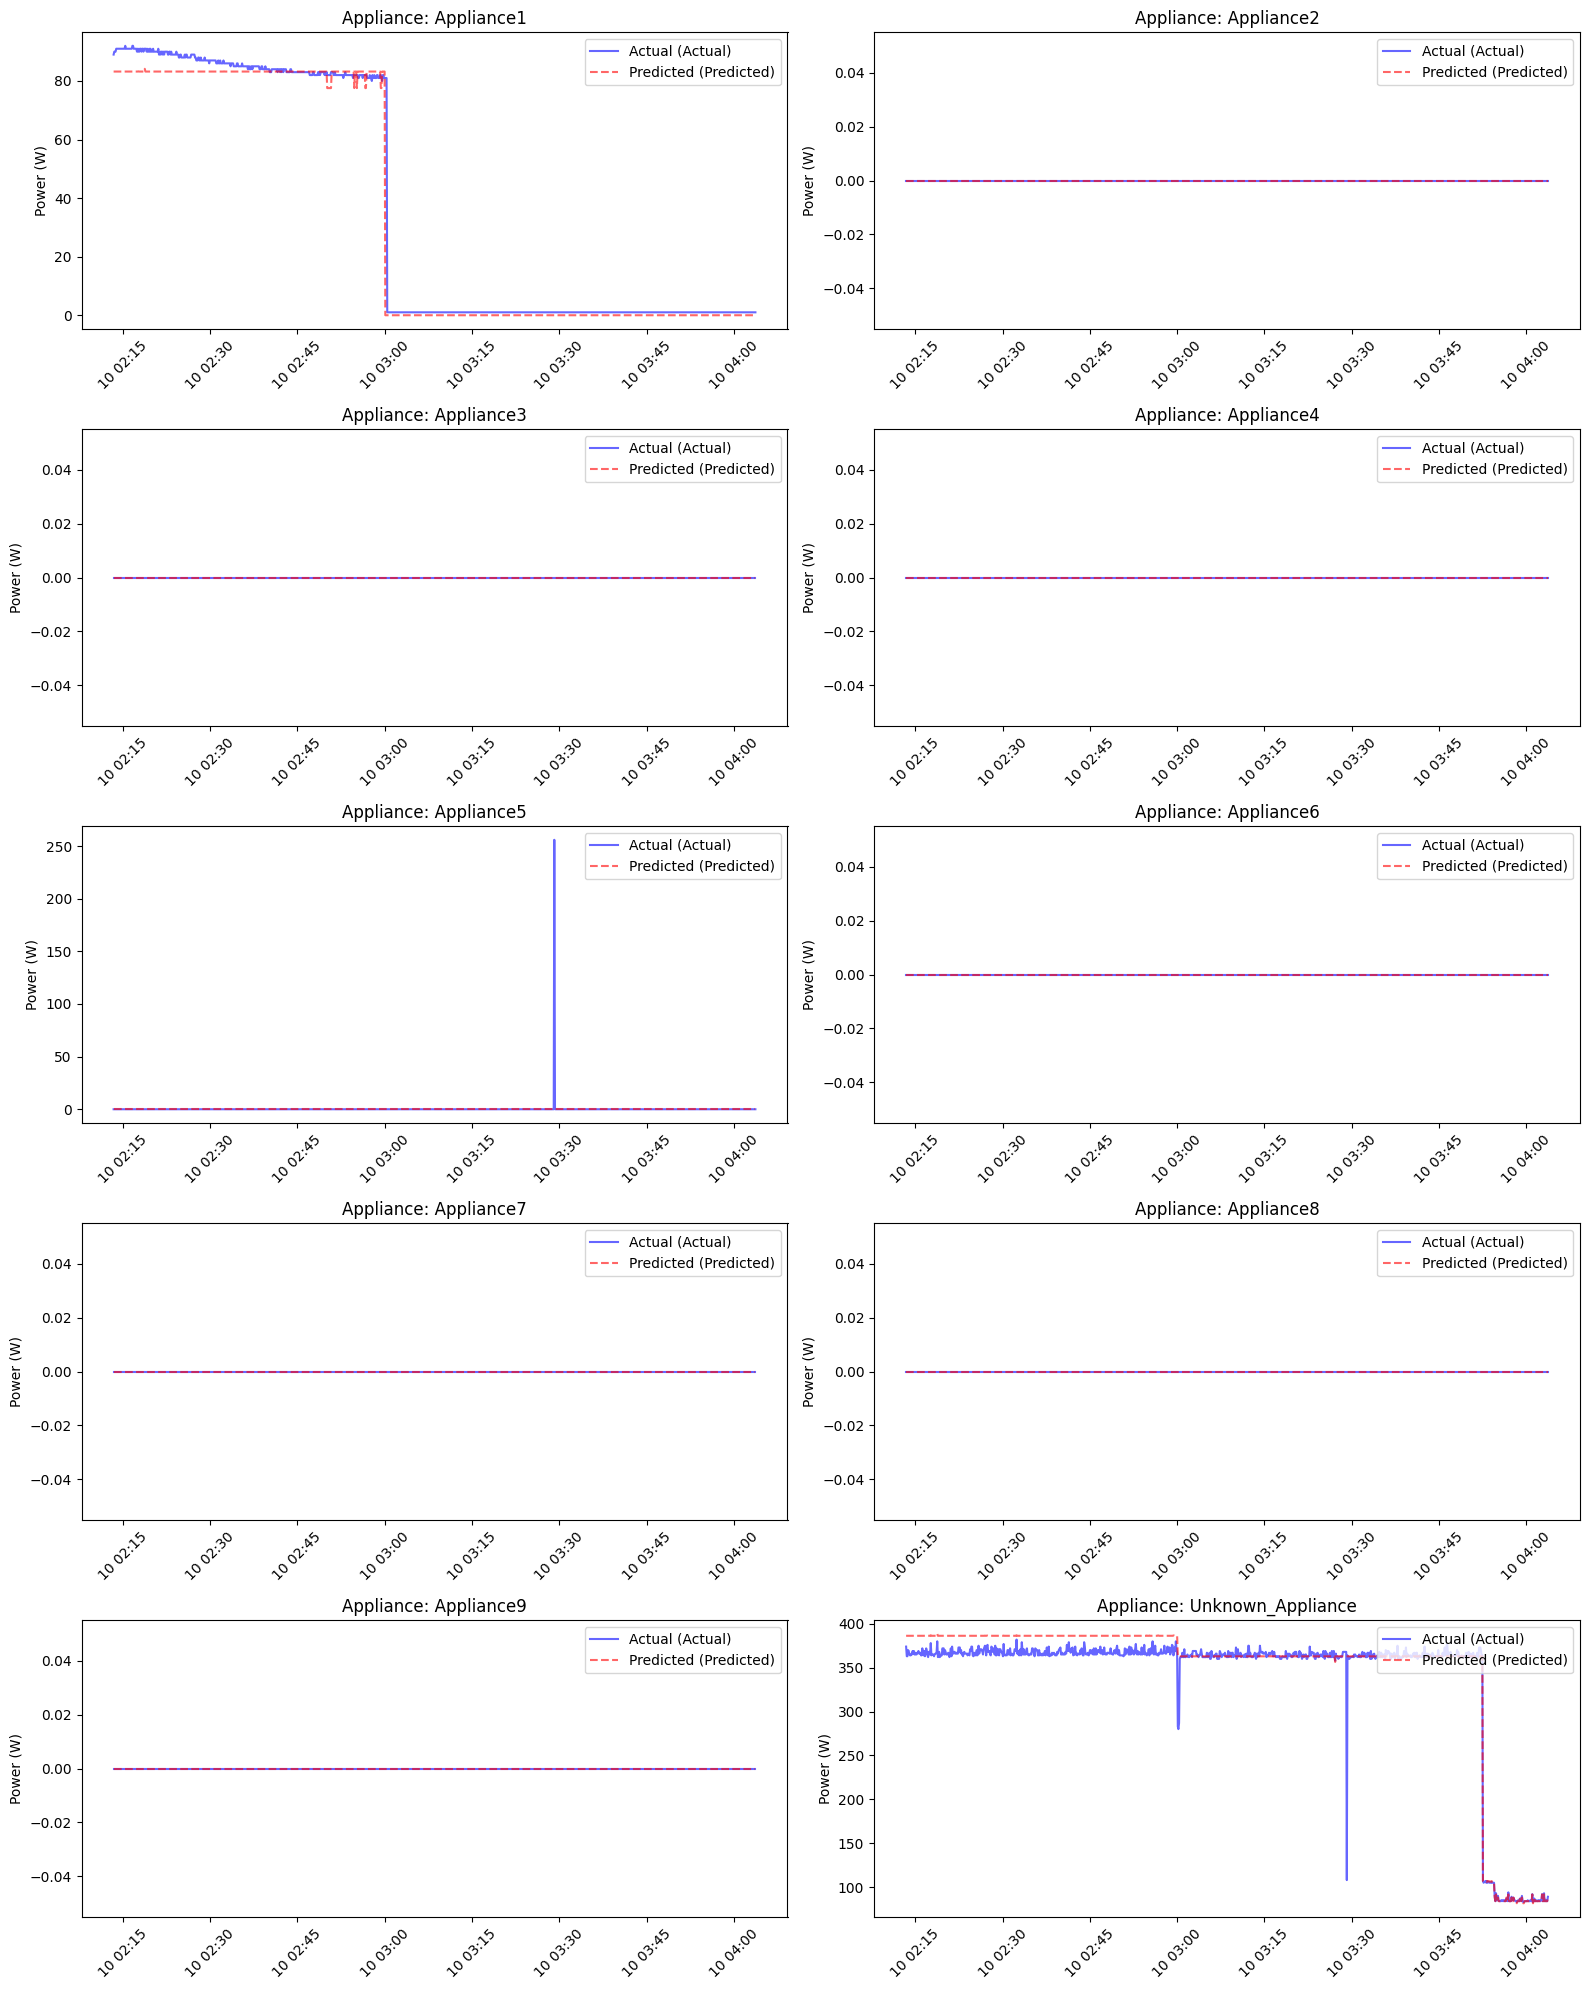

In [ ]:
def plot_10_appliances(y_test, y_pred, time_test):
    appliance_names = list_9_appliances + ['Unknown_Appliance']
    
    fig, axes = plt.subplots(5, 2, figsize=(16, 20))
    axes = axes.flatten()
    
    plot_length = 1000 
    
    for i in range(10):
        axes[i].plot(time_test.iloc[:plot_length], y_test.iloc[:plot_length, i], 
                     label='Actual (Actual)', color='blue', alpha=0.6)
        axes[i].plot(time_test.iloc[:plot_length], y_pred[:plot_length, i], 
                     label='Predicted (Predicted)', color='red', alpha=0.6, linestyle='--')
        
        axes[i].set_title(f'Appliance: {appliance_names[i]}')
        axes[i].set_ylabel('Power (W)')
        axes[i].legend(loc='upper right')
        
        plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

plot_10_appliances(y_test, y_pred, time_test)